# Analisis de Temperatura — Tegucigalpa y San Pedro Sula

**Asignatura:** Big Data  
**Proyecto:** Sistema de Sensores Climaticos con Load Balancer  
**Fuente de datos:** PostgreSQL (lecturas capturadas via Open-Meteo)  
**Estudiante:** Anyelo Favian Rivera Galindo  
**Fecha:** 06/06/2026

## Descripcion

Este notebook lee los datos de temperatura almacenados por las tres instancias de la API en la base de datos PostgreSQL. Luego los ordena, analiza y genera graficos del comportamiento de la temperatura durante el dia para Tegucigalpa y San Pedro Sula.

---
## 1. Conexion a la base de datos y carga de datos

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import psycopg2
from datetime import datetime

# Conexion a PostgreSQL
# Si corres el notebook desde tu PC (fuera de Docker): host="localhost"
# Si corres dentro de Docker: host="postgres"
conn = psycopg2.connect(
    host="localhost",
    port=5432,
    dbname="clima_db",
    user="clima_user",
    password="clima_pass"
)

query = """
    SELECT ciudad, temperatura, unidad, latitud, longitud, instancia, fecha_hora
    FROM lecturas
    ORDER BY fecha_hora ASC
"""

df = pd.read_sql(query, conn)
conn.close()

df["fecha_hora"] = pd.to_datetime(df["fecha_hora"])
df["hora"] = df["fecha_hora"].dt.strftime("%H:%M")

print(f"Total de lecturas cargadas: {len(df)}")
print(f"Rango: {df['fecha_hora'].min()} a {df['fecha_hora'].max()}")
df.head(10)

Total de lecturas cargadas: 239
Rango: 2026-06-06 04:33:34.703091 a 2026-06-06 05:45:14.172709


C:\Users\marie\AppData\Local\Temp\ipykernel_28108\4231040034.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,ciudad,temperatura,unidad,latitud,longitud,instancia,fecha_hora,hora
0,Tegucigalpa,20.8,C,14.0818,-87.2068,API-1,2026-06-06 04:33:34.703091,04:33
1,San Pedro Sula,26.6,C,15.5000,-88.0333,API-2,2026-06-06 04:33:35.440027,04:33
2,Tegucigalpa,20.8,C,14.0818,-87.2068,API-3,2026-06-06 04:34:06.198146,04:34
3,San Pedro Sula,26.6,C,15.5000,-88.0333,API-1,2026-06-06 04:34:06.976115,04:34
4,Tegucigalpa,20.8,C,14.0818,-87.2068,API-1,2026-06-06 04:34:37.723044,04:34
5,San Pedro Sula,26.6,C,15.5000,-88.0333,API-2,2026-06-06 04:34:38.414246,04:34
6,Tegucigalpa,20.8,C,14.0818,-87.2068,API-1,2026-06-06 04:35:09.155658,04:35
7,San Pedro Sula,26.6,C,15.5000,-88.0333,API-2,2026-06-06 04:35:09.890718,04:35
8,Tegucigalpa,20.8,C,14.0818,-87.2068,API-3,2026-06-06 04:35:40.664824,04:35
9,San Pedro Sula,26.6,C,15.5000,-88.0333,API-1,2026-06-06 04:35:41.430239,04:35


---
## 2. Vista general de los datos

In [4]:
print("Informacion general del DataFrame:")
print(df.info())
print()
print("Lecturas por ciudad:")
print(df["ciudad"].value_counts())
print()
print("Lecturas por instancia de API:")
print(df["instancia"].value_counts())

Informacion general del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 239 entries, 0 to 238
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   ciudad       239 non-null    str           
 1   temperatura  239 non-null    float64       
 2   unidad       239 non-null    str           
 3   latitud      239 non-null    float64       
 4   longitud     239 non-null    float64       
 5   instancia    239 non-null    str           
 6   fecha_hora   239 non-null    datetime64[us]
 7   hora         239 non-null    str           
dtypes: datetime64[us](1), float64(3), str(4)
memory usage: 15.1 KB
None

Lecturas por ciudad:
ciudad
Tegucigalpa       125
San Pedro Sula    114
Name: count, dtype: int64

Lecturas por instancia de API:
instancia
API-2    81
API-1    80
API-3    78
Name: count, dtype: int64


---
## 3. Estadisticas de temperatura por ciudad

In [5]:
stats = df.groupby("ciudad")["temperatura"].agg(
    Lecturas="count",
    Minima="min",
    Maxima="max",
    Promedio="mean",
    Desviacion="std"
).round(2)

print("Estadisticas de temperatura por ciudad:")
print(stats)

Estadisticas de temperatura por ciudad:
                Lecturas  Minima  Maxima  Promedio  Desviacion
ciudad                                                        
San Pedro Sula       114    25.8    26.6     26.25        0.21
Tegucigalpa          125    20.8    20.9     20.80        0.01


---
## 4. Grafico: Temperatura a lo largo del dia por ciudad

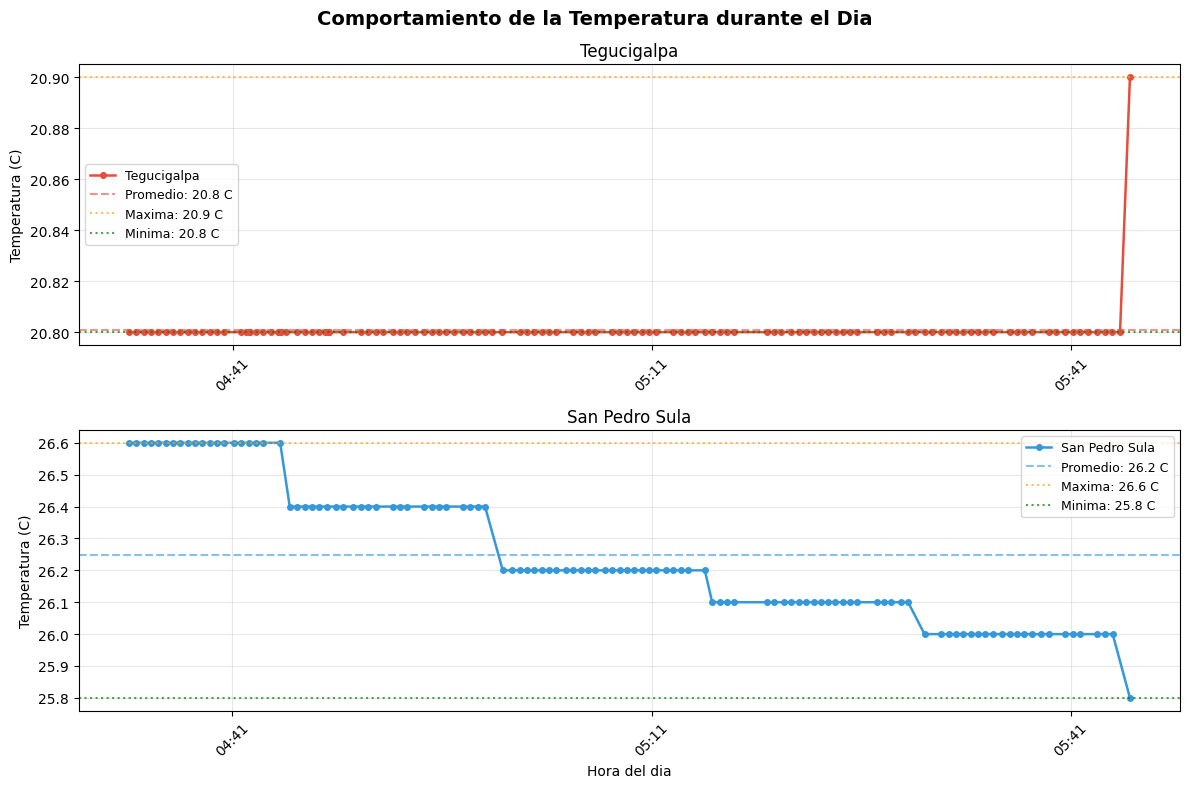

Grafico guardado.


In [6]:
colores = {"Tegucigalpa": "#E74C3C", "San Pedro Sula": "#3498DB"}
ciudades = df["ciudad"].unique()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle("Comportamiento de la Temperatura durante el Dia", fontsize=14, fontweight="bold")

for i, ciudad in enumerate(ciudades):
    datos = df[df["ciudad"] == ciudad].copy()
    ax    = axes[i]
    color = colores.get(ciudad, "gray")

    ax.plot(datos["fecha_hora"], datos["temperatura"],
            marker="o", markersize=4, linewidth=1.8, color=color, label=ciudad)
    ax.axhline(datos["temperatura"].mean(), color=color, linestyle="--", alpha=0.6,
               label=f"Promedio: {datos['temperatura'].mean():.1f} C")
    ax.axhline(datos["temperatura"].max(), color="orange", linestyle=":", alpha=0.7,
               label=f"Maxima: {datos['temperatura'].max():.1f} C")
    ax.axhline(datos["temperatura"].min(), color="green",  linestyle=":", alpha=0.7,
               label=f"Minima: {datos['temperatura'].min():.1f} C")
    ax.set_title(ciudad, fontsize=12)
    ax.set_ylabel("Temperatura (C)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Hora del dia")
plt.tight_layout()
plt.savefig("grafico_temperatura_por_ciudad.png", dpi=150, bbox_inches="tight")
plt.show()
print("Grafico guardado.")

---
## 5. Grafico comparativo: Tegucigalpa vs San Pedro Sula

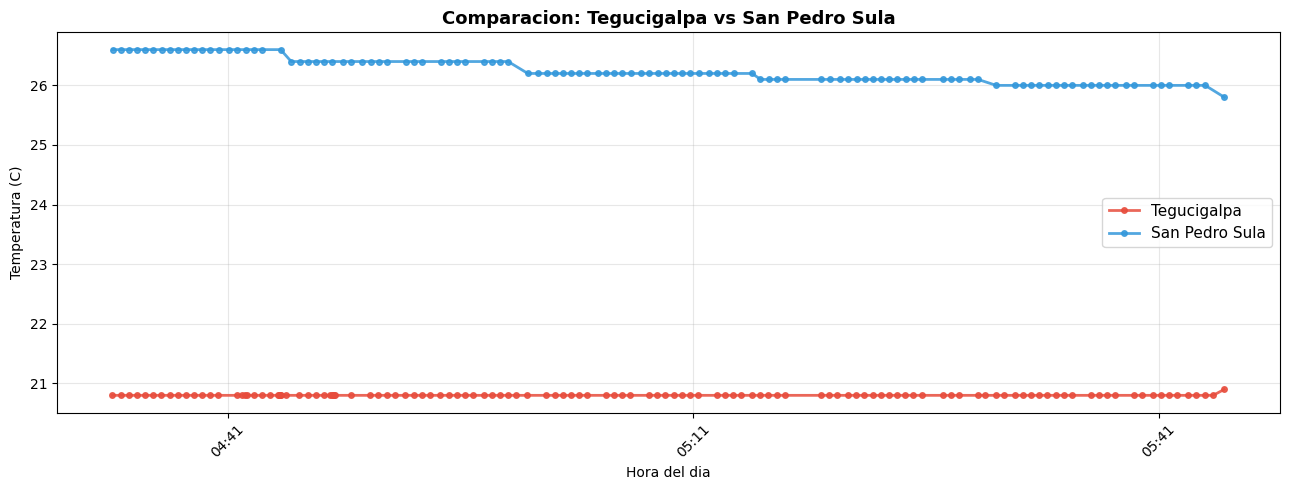

In [7]:
fig, ax = plt.subplots(figsize=(13, 5))

for ciudad, color in colores.items():
    datos = df[df["ciudad"] == ciudad]
    if not datos.empty:
        ax.plot(datos["fecha_hora"], datos["temperatura"],
                marker="o", markersize=4, linewidth=2, color=color,
                label=ciudad, alpha=0.85)

ax.set_title("Comparacion: Tegucigalpa vs San Pedro Sula", fontsize=13, fontweight="bold")
ax.set_xlabel("Hora del dia")
ax.set_ylabel("Temperatura (C)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=30))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("grafico_comparativo.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Evidencia del balanceo de carga

Si Nginx esta distribuyendo correctamente, las peticiones deben estar repartidas de forma aproximadamente equitativa entre API-1, API-2 y API-3.

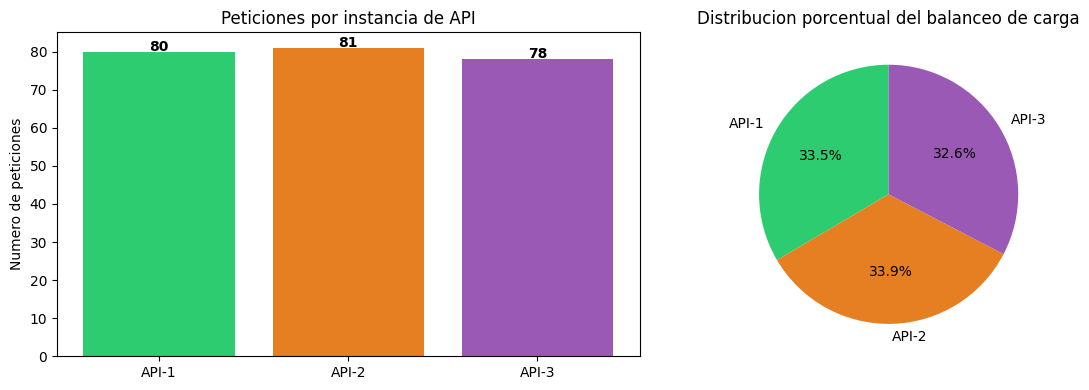

Distribucion de peticiones:
  API-1: 80 peticiones (33.5%)
  API-2: 81 peticiones (33.9%)
  API-3: 78 peticiones (32.6%)


In [8]:
conteo = df["instancia"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(conteo.index, conteo.values, color=["#2ECC71","#E67E22","#9B59B6"])
axes[0].set_title("Peticiones por instancia de API")
axes[0].set_ylabel("Numero de peticiones")
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 0.2, str(v), ha="center", fontweight="bold")

axes[1].pie(conteo.values, labels=conteo.index, autopct="%1.1f%%",
            colors=["#2ECC71","#E67E22","#9B59B6"], startangle=90)
axes[1].set_title("Distribucion porcentual del balanceo de carga")

plt.tight_layout()
plt.savefig("grafico_balanceo.png", dpi=150, bbox_inches="tight")
plt.show()

print("Distribucion de peticiones:")
for inst, cant in conteo.items():
    print(f"  {inst}: {cant} peticiones ({cant/conteo.sum()*100:.1f}%)")

---
## 7. Resumen final

In [9]:
print("=" * 50)
print("  RESUMEN DEL ANALISIS CLIMATICO")
print("=" * 50)

for ciudad in df["ciudad"].unique():
    datos = df[df["ciudad"] == ciudad]
    print(f"\n  {ciudad}")
    print(f"    Lecturas      : {len(datos)}")
    print(f"    Minima        : {datos['temperatura'].min():.1f} C")
    print(f"    Maxima        : {datos['temperatura'].max():.1f} C")
    print(f"    Promedio      : {datos['temperatura'].mean():.1f} C")

print(f"\n  BALANCEO DE CARGA")
for inst, cant in df["instancia"].value_counts().sort_index().items():
    print(f"    {inst}: {cant} peticiones")

print(f"\n  Total lecturas en la BD: {len(df)}")
print("=" * 50)

  RESUMEN DEL ANALISIS CLIMATICO

  Tegucigalpa
    Lecturas      : 125
    Minima        : 20.8 C
    Maxima        : 20.9 C
    Promedio      : 20.8 C

  San Pedro Sula
    Lecturas      : 114
    Minima        : 25.8 C
    Maxima        : 26.6 C
    Promedio      : 26.2 C

  BALANCEO DE CARGA
    API-1: 80 peticiones
    API-2: 81 peticiones
    API-3: 78 peticiones

  Total lecturas en la BD: 239


---
## Conclusion tecnica

El sistema demuestra como el **balanceo de carga con Nginx** distribuye las peticiones entre tres instancias de API de forma equitativa, evitando que una sola instancia se sobrecargue. Si una API cae, las otras dos siguen respondiendo sin interrumpir el servicio.

La **persistencia en PostgreSQL** permite acumular el historial completo de temperaturas y analizarlo desde Jupyter. Esto conecta directamente con Big Data: en un sistema real, decenas o cientos de sensores enviarian datos continuamente a traves del load balancer, y sin una base de datos los datos se perderian con cada peticion.

Este tipo de arquitectura (sensores -> LB -> multiples APIs -> BD -> analisis) es la base de plataformas de IoT y monitoreo en tiempo real a gran escala.